# Quantitative Evaluation of SPECT Reconstruction

In this notebook, reconstruction performance is evaluated against the **known digital NEMA activity distribution**.

Recovery coefficients (RCs) are used to investigate:

- reconstruction convergence as a function of subiteration;
- the effect of **resolution modelling**;
- the dependence of recovery on sphere size; and
- whether the recovery behaviour differs substantially between **Tc-99m and Lu-177**.

The reconstructions evaluated here were generated from the SIMIND projection data in the preceding notebooks.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
import sirf.STIR as spect

sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils

demo_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")

## Recovery Coefficient and Image Calibration

The six NEMA spheres provide regions of known activity concentration. For each sphere, the **recovery coefficient (RC)** compares the activity recovered in the reconstructed image with the known activity in the digital source distribution.

An RC of **1** represents complete recovery. Smaller spheres are expected to have lower RCs because of the finite spatial resolution of the imaging system.

### Image calibration factor

The image calibration factor (ICF) was determined independently for each radionuclide using **SIMIND simulations of virtual cylindrical phantoms containing known activity**.

The calibration phantoms were reconstructed to **100 subiterations**, where the reconstruction had converged. Counts were summed within a **dilated cylindrical mask** designed to encompass the complete cylinder and activity extending beyond its nominal boundary because of spatial resolution.

The calibration factor is defined as

ICF = C(recon) / A(known)

where C(recon) is the reconstructed signal summed within the calibration mask and A(known) is the known activity in the simulated cylinder. Reconstructed images are therefore converted to activity using

A(recon) = C(recon) / ICF

The ICF is obtained from a **separate calibration simulation**, independently of the NEMA phantom evaluated below. A single radionuclide-specific ICF is applied to both OSEM and OSEM-RM reconstructions.

In [2]:
verbose = False

config = {
    "tc99m": {
        "label": "Tc-99m",
        "image_type": "tc99m_128",
        "source_name": "nema_tc_act.hv",
        "masks_name": "masks_tc.npz",
        "icf": 1485.8441,
    },
    "lu177": {
        "label": "Lu-177",
        "image_type": "lu177_128",
        "source_name": "nema_lu_act.hv",
        "masks_name": "masks_lu.npz",
        "icf": 109.264725,
    },
}

sphere_diameters_mm = [13, 17, 22, 28, 37, 60]
subiterations = np.arange(10, 101, 10)

## Load and Evaluate the Reconstruction Series

A reusable helper function loads the known source distribution, sphere masks and complete reconstruction series for one radionuclide and reconstruction method.

The same analysis is then applied consistently to Tc-99m and Lu-177, with and without resolution modelling.

In [3]:
def evaluate_reconstruction(nuclide, recon_type):
    """Load a reconstruction series and calculate NEMA sphere recovery coefficients."""

    cfg = config[nuclide]
    sim_dir = demo_path / "simind_data" / cfg["image_type"]
    input_dir = sim_dir / "input"
    recon_dir = sim_dir / "recons" / recon_type

    source = spect.ImageData(
        str(input_dir / cfg["source_name"])
    ).as_array()

    masks = dict(np.load(input_dir / cfg["masks_name"]))

    recon_prefix = f"{nuclide}_sim_{recon_type}"
    reconstructions = {
        str(it): spect.ImageData(
            str(recon_dir / f"{recon_prefix}_{it}.hv")
        ).as_array()
        for it in subiterations
    }

    rc = utils.calculate_recovery_coefficients(
        source=source,
        recon_dict=reconstructions,
        masks_dict=masks,
        subiterations=subiterations,
        icf=cfg["icf"],
        verbose=verbose,
    )

    return {
        "source": source,
        "masks": masks,
        "reconstructions": reconstructions,
        "rc": rc,
        "icf": cfg["icf"],
    }


results = {
    nuclide: {
        recon_type: evaluate_reconstruction(nuclide, recon_type)
        for recon_type in ("osem", "osem_rm")
    }
    for nuclide in ("tc99m", "lu177")
}

## Effect of Resolution Modelling

For each radionuclide, the OSEM and OSEM-RM recovery curves are displayed **side by side** rather than overlaid.

Both panels use the same axes and sphere colours, making it easier to compare the convergence behaviour without crowding each graph. The left panel shows conventional OSEM and the right panel shows OSEM with resolution modelling.


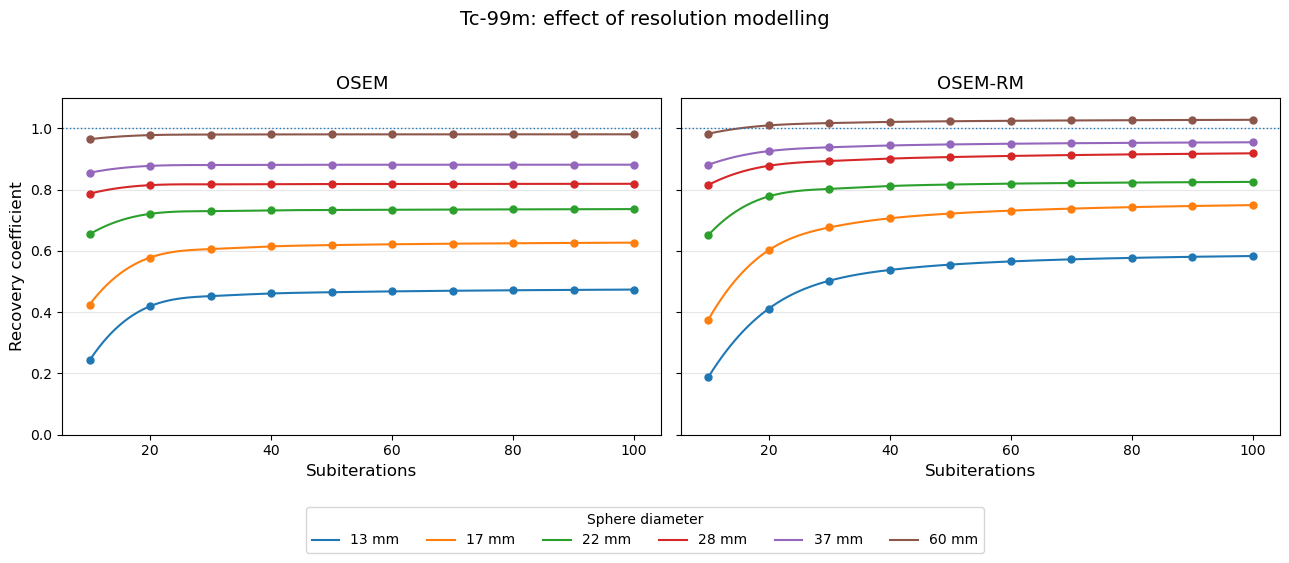

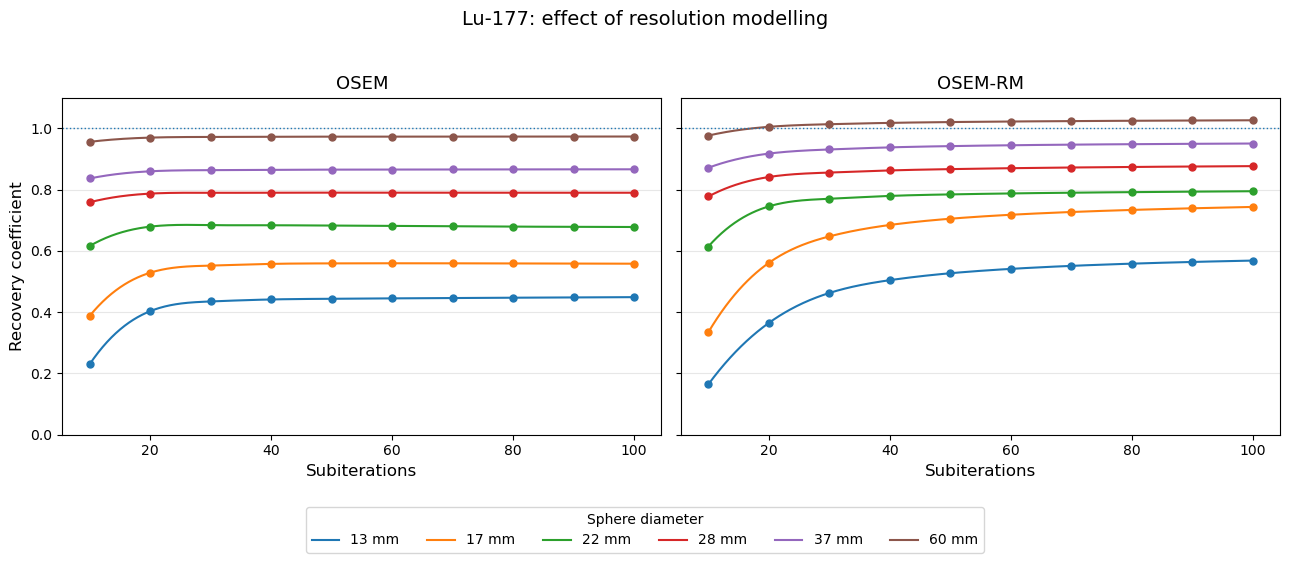

In [4]:
def plot_resolution_modelling_comparison(nuclide, ylim=(0, 1.1)):
    label = config[nuclide]["label"]
    rc_osem = results[nuclide]["osem"]["rc"]
    rc_rm = results[nuclide]["osem_rm"]["rc"]

    subit_smooth = np.linspace(
        subiterations.min(),
        subiterations.max(),
        500,
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13, 5.5),
        sharex=True,
        sharey=True,
    )

    methods = [
        ("OSEM", rc_osem),
        ("OSEM-RM", rc_rm),
    ]

    for ax, (method_name, rc_data) in zip(axes, methods):
        for i, diameter in enumerate(sphere_diameters_mm):
            spline = make_interp_spline(
                subiterations,
                rc_data[:, i],
                k=3,
            )
            rc_smooth = spline(subit_smooth)

            line, = ax.plot(
                subit_smooth,
                rc_smooth,
                label=f"{diameter} mm",
            )

            # Retain the measured reconstruction points.
            ax.scatter(
                subiterations,
                rc_data[:, i],
                color=line.get_color(),
                s=25,
                zorder=3,
            )

        ax.axhline(1.0, linestyle=":", linewidth=1)
        ax.set_xlabel("Subiterations", fontsize=12)
        ax.set_title(method_name, fontsize=13)
        ax.set_ylim(*ylim)
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Recovery coefficient", fontsize=12)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Sphere diameter",
        ncol=6,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
    )

    fig.suptitle(
        f"{label}: effect of resolution modelling",
        fontsize=14,
    )
    fig.tight_layout(rect=(0, 0.10, 1, 0.95))
    plt.show()


plot_resolution_modelling_comparison("tc99m")
plot_resolution_modelling_comparison("lu177")


## Tc-99m versus Lu-177

The OSEM-RM recovery coefficients are now compared directly for each sphere size.

The purpose is to determine whether the **overall convergence and recovery behaviour** is broadly similar under the simulated acquisition and reconstruction conditions, rather than assuming equivalence in advance.

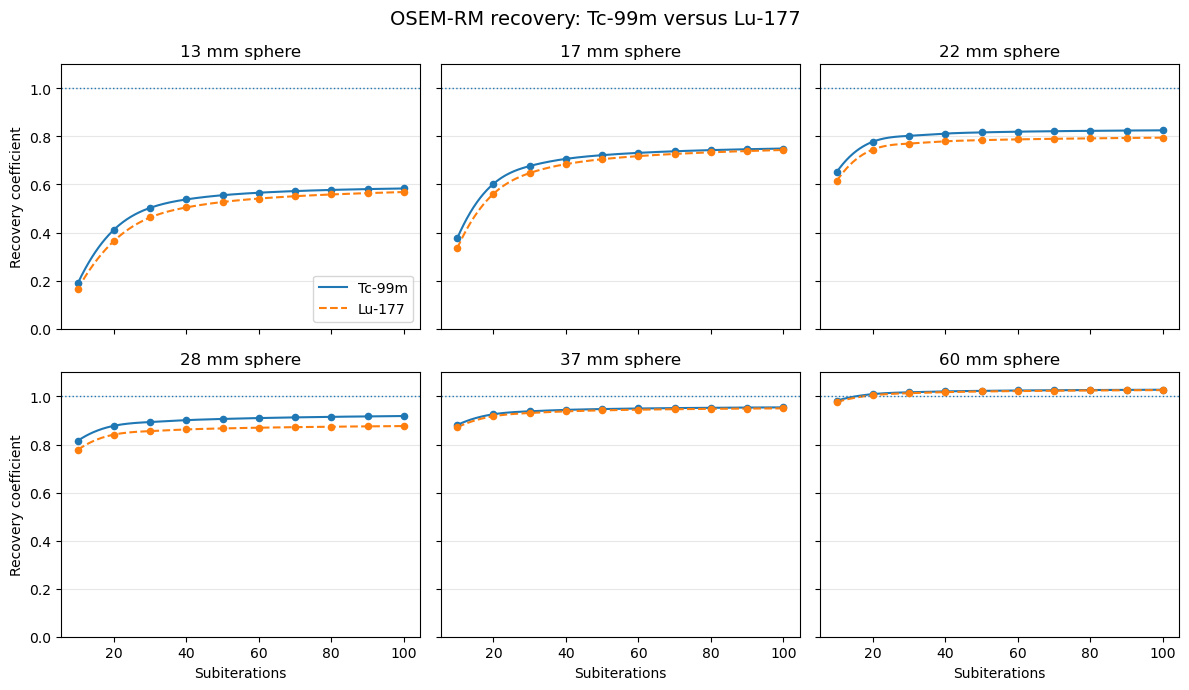

In [5]:
def plot_radionuclide_comparison(ylim=(0, 1.1)):
    rc_tc = results["tc99m"]["osem_rm"]["rc"]
    rc_lu = results["lu177"]["osem_rm"]["rc"]

    subit_smooth = np.linspace(
        subiterations.min(),
        subiterations.max(),
        500,
    )

    fig, axes = plt.subplots(
        2, 3,
        figsize=(12, 7),
        sharex=True,
        sharey=True,
    )
    axes = axes.ravel()

    for i, (ax, diameter) in enumerate(zip(axes, sphere_diameters_mm)):
        for rc_data, radionuclide_label, linestyle in (
            (rc_tc, "Tc-99m", "-"),
            (rc_lu, "Lu-177", "--"),
        ):
            spline = make_interp_spline(
                subiterations,
                rc_data[:, i],
                k=3,
            )
            rc_smooth = spline(subit_smooth)

            line, = ax.plot(
                subit_smooth,
                rc_smooth,
                linestyle=linestyle,
                label=radionuclide_label,
            )
            ax.scatter(
                subiterations,
                rc_data[:, i],
                color=line.get_color(),
                s=20,
                zorder=3,
            )

        ax.axhline(1.0, linestyle=":", linewidth=1)
        ax.set_title(f"{diameter} mm sphere")
        ax.set_ylim(*ylim)
        ax.grid(axis="y", alpha=0.3)

    for ax in axes[3:]:
        ax.set_xlabel("Subiterations")
    for ax in axes[::3]:
        ax.set_ylabel("Recovery coefficient")

    axes[0].legend()
    fig.suptitle(
        "OSEM-RM recovery: Tc-99m versus Lu-177",
        fontsize=14,
    )
    fig.tight_layout()
    plt.show()


plot_radionuclide_comparison()


## Visual Comparison with the Known Source Distribution

The converged OSEM-RM reconstruction is finally compared with the known digital source distribution for each radionuclide.

The difference image is defined as

(reconstruction)-(known source)

with a symmetric colour scale around zero so that positive and negative differences can be interpreted consistently.

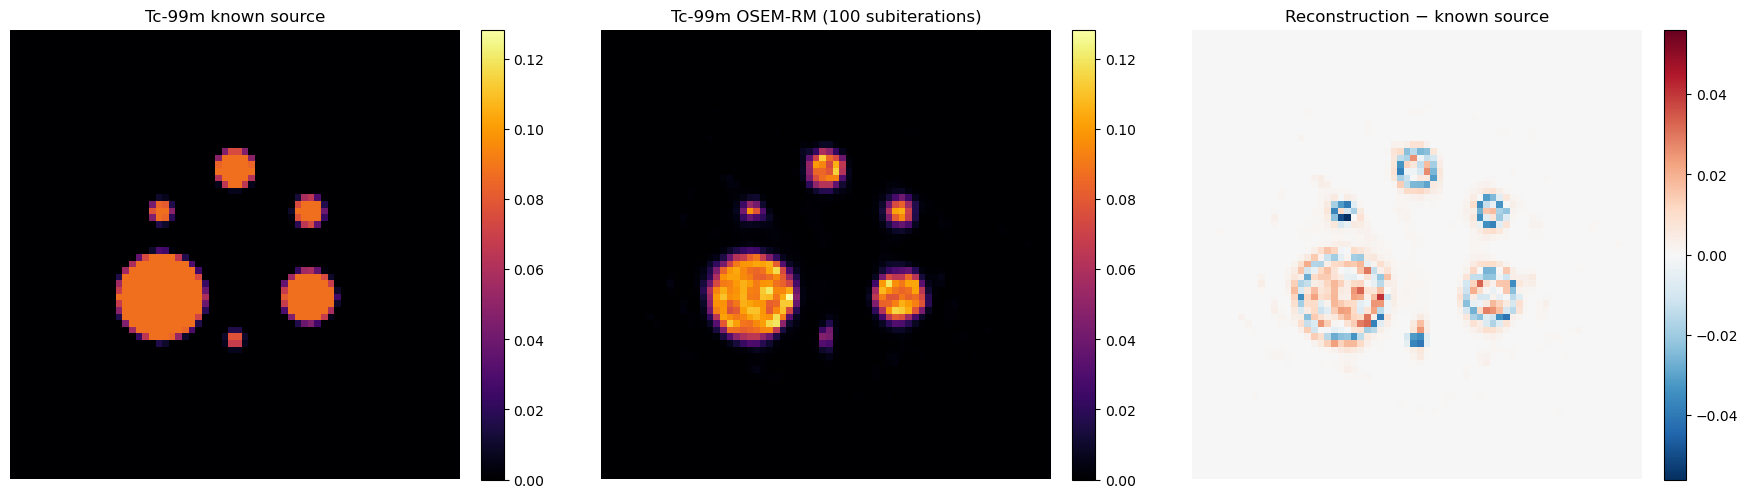

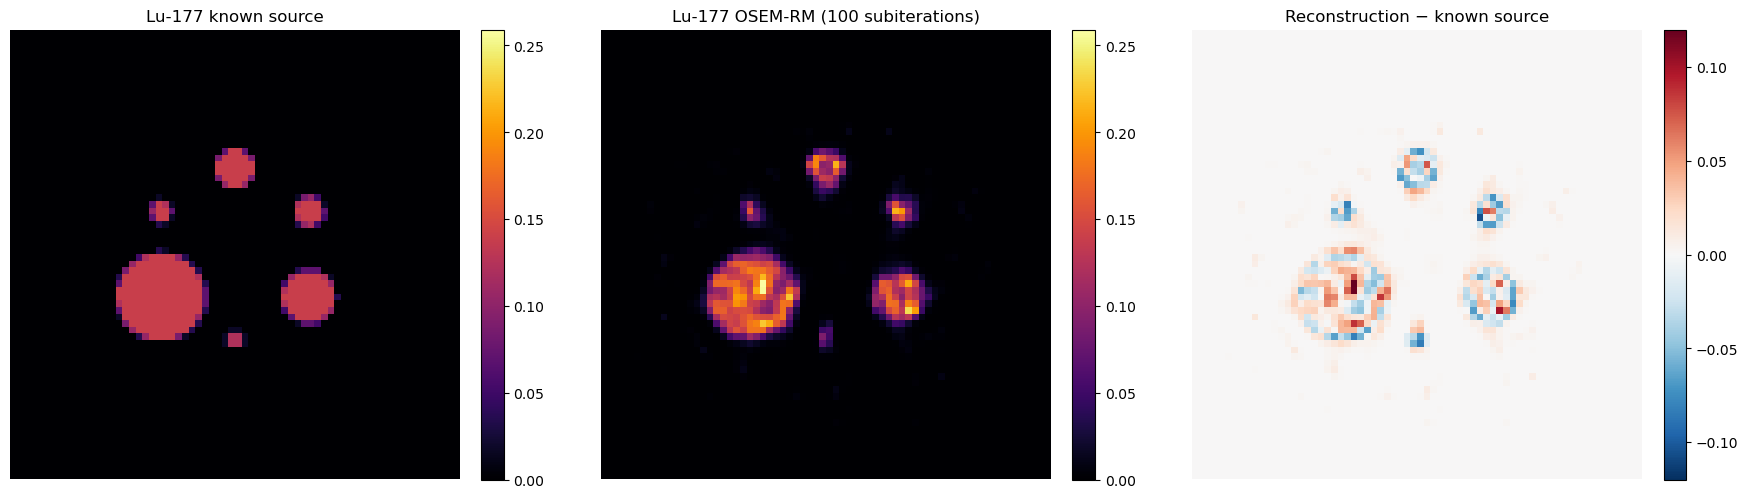

In [7]:
idx = (56, slice(30, 98), slice(30, 98))
display_subiteration = 100

for nuclide in ("tc99m", "lu177"):
    label = config[nuclide]["label"]
    result = results[nuclide]["osem_rm"]

    source = result["source"]
    reconstruction = (
        result["reconstructions"][str(display_subiteration)]
        / result["icf"]
    )
    difference = reconstruction - source

    vmax = max(np.max(source[idx]), np.max(reconstruction[idx]))
    diff_max = np.max(np.abs(difference[idx]))

    utils.display_arr(
        arr_3d=[source, reconstruction, difference],
        idx=idx,
        vmin=[0, 0, -diff_max],
        vmax=[vmax, vmax, diff_max],
        titles=[
            f"{label} known source",
            f"{label} OSEM-RM ({display_subiteration} subiterations)",
            "Reconstruction − known source",
        ],
        cmap=["inferno", "inferno", "RdBu_r"],
    )

## Conclusions

- Recovery depends strongly on **sphere size** because of the finite spatial resolution of SPECT.
- The convergence curves allow the effect of **resolution modelling** to be assessed directly against conventional OSEM.
- Tc-99m and Lu-177 are evaluated using the same quantitative framework, allowing their recovery behaviour to be compared under controlled simulated conditions.
- Because the underlying digital activity distributions are known, SIMIND simulation provides a controlled framework for **quantitative reconstruction evaluation and validation**.

The generated figures should be used to judge the extent to which Tc-99m and Lu-177 recovery is similar; that conclusion is not assumed in advance.